# 🧠 Baseline U-Net — Masked Face Super Resolution

Premier modèle du projet. On entraîne **deux U-Nets identiques en parallèle**, un par tâche :
- `inpainting` : 128×128 masked → 128×128 unmasked
- `sr` : 64×64 masked → 128×128 unmasked (super-résolution 2×)

→ Comparaison finale sur PSNR / SSIM pour choisir la tâche à approfondir dans la suite (GAN, diffusion).

## Environnement
- **Kaggle Notebooks** — GPU T4 (16 GB VRAM)
- **Mixed precision (AMP)** activé → ~2× plus rapide sur T4
- **Dataset** : `splitted-masked-ffhq-cropped` (part1 + part2, 20k paires)

## Design
- **Architecture** : U-Net ~8M params, BatchNorm, ReLU, tanh output
- **SR géré par pre-upsampling bicubic** dans le modèle → même architecture pour les 2 tâches
- **Loss** : `L1 + 0.1 × perceptual (VGG16 relu3_3)` — L1 pour la fidélité pixel, perceptual pour la netteté structurelle
- **Optimizer** : Adam lr=2e-4, β=(0.5, 0.999) — standard GAN-friendly
- **Epochs** : 10 | **Batch size** : 32

## Plan
1. Setup Kaggle + imports
2. Rechargement de l'index du notebook précédent
3. Dataset & DataLoaders (réimportés, + `num_workers=2`)
4. Architecture U-Net
5. Loss combinée (L1 + VGG perceptual)
6. Métriques PSNR / SSIM
7. Boucle d'entraînement
8. Entraînement tâche `inpainting`
9. Entraînement tâche `sr`
10. Comparaison finale & visualisations
11. Sauvegarde des checkpoints
12. Synthèse

## 1. Setup Kaggle + imports

In [1]:
import os, sys, time, random, json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
import torchvision.transforms.functional as TF

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch: {torch.__version__}")
print(f"Device : {DEVICE}")
if DEVICE.type == 'cuda':
    print(f"GPU    : {torch.cuda.get_device_name(0)} ({torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB)")

PyTorch: 2.10.0+cu128
Device : cuda
GPU    : Tesla T4 (15.6 GB)


In [2]:
# ─── Paths Kaggle vs local (auto-détection robuste) ───
if Path('/kaggle/input').is_dir():
    # Cherche part1 récursivement — gère les sous-dossiers intermédiaires
    matches = [c.parent for c in Path('/kaggle/input').rglob('part1') if c.is_dir()]
    assert len(matches) > 0, (
        "Dataset introuvable. Vérifie que le dataset 'splitted-masked-ffhq-cropped' "
        "est bien ajouté en Input du notebook.\n"
        f"Contenu de /kaggle/input : {list(Path('/kaggle/input').iterdir())}")
    DATA_ROOT = matches[0]
    OUTPUT_DIR = Path('/kaggle/working')
else:
    # Local (ton poste)
    DATA_ROOT = next((c for c in [
        Path.cwd() / 'dataset', Path.cwd().parent / 'dataset',
        Path.cwd() / 'data' / 'raw', Path.cwd().parent / 'data' / 'raw',
    ] if c.is_dir() and (c/'part1').is_dir()), None)
    OUTPUT_DIR = Path.cwd().parent / 'src' / 'models' / 'checkpoints'

assert DATA_ROOT is not None, "Dataset introuvable — ajuste DATA_ROOT manuellement."
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Vérification de la structure
assert (DATA_ROOT / 'part1' / 'train' / 'masked').is_dir(), \
    f"Structure inattendue dans {DATA_ROOT} — part1/train/masked manquant"

print(f"✓ DATA_ROOT  : {DATA_ROOT}")
print(f"✓ OUTPUT_DIR : {OUTPUT_DIR}")
print(f"✓ Structure validée")

✓ DATA_ROOT  : /kaggle/input/datasets/yyazidd/splitted-masked-ffhq-cropped/dataset
✓ OUTPUT_DIR : /kaggle/working
✓ Structure validée


In [3]:
# ─── Hyperparamètres ───
CONFIG = {
    'train_parts' : ['part1', 'part2'],
    'hr_size'     : 128,
    'lr_size'     : 64,          # pour la tâche SR (2× upscaling)
    'batch_size'  : 32,
    'num_workers' : 2,           # Kaggle T4 recommande 2
    'epochs'      : 10,
    'lr'          : 2e-4,
    'betas'       : (0.5, 0.999),
    'base_ch'     : 32,          # largeur du U-Net (32 → ~8M params)
    'lambda_perc' : 0.1,         # poids de la loss perceptuelle
    'use_amp'     : DEVICE.type == 'cuda',
    'val_subset'  : 500,         # images pour validation rapide en cours d'entraînement
}
for k, v in CONFIG.items():
    print(f"  {k:15} = {v}")

  train_parts     = ['part1', 'part2']
  hr_size         = 128
  lr_size         = 64
  batch_size      = 32
  num_workers     = 2
  epochs          = 10
  lr              = 0.0002
  betas           = (0.5, 0.999)
  base_ch         = 32
  lambda_perc     = 0.1
  use_amp         = True
  val_subset      = 500


## 2. Rechargement de l'index

Si `pairs_index.csv` existe (produit par `02_preprocessing.ipynb`), on le recharge. Sinon on le reconstruit.

In [4]:
def build_index(data_dir: Path, parts, splits=('train','val','test')) -> pd.DataFrame:
    rows = []
    for part in parts:
        for split in splits:
            m_dir = data_dir / part / split / 'masked'
            u_dir = data_dir / part / split / 'unmasked'
            if not (m_dir.is_dir() and u_dir.is_dir()): continue
            m = {p.name: p for p in m_dir.glob('*.png')}
            u = {p.name: p for p in u_dir.glob('*.png')}
            for name in sorted(set(m) & set(u)):
                rows.append({'filename': name, 'path_masked': str(m[name]),
                             'path_unmasked': str(u[name]), 'part': part, 'split': split})
    return pd.DataFrame(rows)

# Chercher l'index existant (plusieurs locations possibles)
csv_candidates = [
    Path('/kaggle/working/pairs_index.csv'),
    Path.cwd().parent / 'data' / 'processed' / 'pairs_index.csv',
    Path.cwd() / 'data' / 'processed' / 'pairs_index.csv',
]
idx_csv = next((c for c in csv_candidates if c.is_file()), None)

if idx_csv is not None:
    index_df = pd.read_csv(idx_csv)
    # Important : les chemins peuvent être périmés (machine différente) → on rebuild les paths
    needs_rebuild = not Path(index_df.iloc[0]['path_masked']).is_file()
    if needs_rebuild:
        print(f"⚠️ Chemins du CSV périmés → reconstruction depuis {DATA_ROOT}")
        index_df = build_index(DATA_ROOT, CONFIG['train_parts'])
    else:
        print(f"✓ Index chargé depuis {idx_csv}")
else:
    print(f"⚠️ CSV introuvable → reconstruction depuis {DATA_ROOT}")
    index_df = build_index(DATA_ROOT, CONFIG['train_parts'])

print(f"\n{len(index_df):,} paires indexées")
print(index_df.groupby(['part','split']).size().unstack(fill_value=0))

⚠️ CSV introuvable → reconstruction depuis /kaggle/input/datasets/yyazidd/splitted-masked-ffhq-cropped/dataset

20,000 paires indexées
split  test  train   val
part                    
part1  1000   8000  1000
part2  1000   8000  1000


## 3. Dataset & DataLoaders

Réimport de la classe (copie identique à `02_preprocessing`, pour que ce notebook soit autonome).

In [5]:
class MaskedFaceDataset(Dataset):
    MEAN = [0.5, 0.5, 0.5]
    STD  = [0.5, 0.5, 0.5]
    def __init__(self, df, task='inpainting', lr_size=64, hr_size=128, augment=False):
        assert task in ('inpainting','sr')
        self.df = df.reset_index(drop=True)
        self.task, self.lr_size, self.hr_size, self.augment = task, lr_size, hr_size, augment
        self._norm = transforms.Normalize(self.MEAN, self.STD)
    def __len__(self): return len(self.df)
    def __getitem__(self, i):
        row = self.df.iloc[i]
        m = Image.open(row['path_masked']).convert('RGB')
        u = Image.open(row['path_unmasked']).convert('RGB')
        if m.size != (self.hr_size, self.hr_size): m = m.resize((self.hr_size,)*2, Image.BICUBIC)
        if u.size != (self.hr_size, self.hr_size): u = u.resize((self.hr_size,)*2, Image.BICUBIC)
        if self.augment and random.random() < 0.5:
            m = TF.hflip(m); u = TF.hflip(u)
        if self.task == 'sr':
            m = m.resize((self.lr_size,)*2, Image.BICUBIC)
        return self._norm(TF.to_tensor(m)), self._norm(TF.to_tensor(u))
    @classmethod
    def denormalize(cls, t):
        t = t.clone().cpu()
        for c, (m,s) in enumerate(zip(cls.MEAN, cls.STD)):
            (t[c] if t.ndim==3 else t[:,c]).mul_(s).add_(m)
        return t.clamp(0,1)

def build_dataloaders(index_df, task, cfg):
    loaders = {}
    for split in ['train','val','test']:
        sub = index_df[index_df['split'] == split]
        if len(sub) == 0: continue
        ds = MaskedFaceDataset(sub, task=task, lr_size=cfg['lr_size'],
                               hr_size=cfg['hr_size'], augment=(split=='train'))
        loaders[split] = DataLoader(
            ds, batch_size=cfg['batch_size'],
            shuffle=(split=='train'),
            num_workers=cfg['num_workers'],
            pin_memory=(DEVICE.type=='cuda'),
            drop_last=(split=='train'))
    return loaders

# Test quick shapes
_tmp = build_dataloaders(index_df.head(100), 'sr', CONFIG)
_xb, _yb = next(iter(_tmp['train']))
print(f"✓ SR shapes : x={tuple(_xb.shape)}  y={tuple(_yb.shape)}")
del _tmp, _xb, _yb

✓ SR shapes : x=(32, 3, 64, 64)  y=(32, 3, 128, 128)


## 4. Architecture U-Net

U-Net encodeur-décodeur classique avec 4 niveaux down/up et skip connections. Un `Upsample(scale_factor)` en amont gère la tâche SR sans changer l'architecture du cœur.

In [6]:
def conv_block(in_c, out_c):
    return nn.Sequential(
        nn.Conv2d(in_c, out_c, 3, padding=1, bias=False),
        nn.BatchNorm2d(out_c), nn.ReLU(inplace=True),
        nn.Conv2d(out_c, out_c, 3, padding=1, bias=False),
        nn.BatchNorm2d(out_c), nn.ReLU(inplace=True),
    )

class UNet(nn.Module):
    """U-Net 4-niveaux, output tanh → [-1,1].
    scale_factor > 1 active un pre-upsampling bicubic pour la tâche SR."""
    def __init__(self, in_ch=3, out_ch=3, base=32, scale_factor=1):
        super().__init__()
        self.pre = nn.Upsample(scale_factor=scale_factor, mode='bicubic', align_corners=False) \
                   if scale_factor > 1 else nn.Identity()
        c = base
        self.enc1 = conv_block(in_ch, c)
        self.enc2 = conv_block(c, c*2)
        self.enc3 = conv_block(c*2, c*4)
        self.enc4 = conv_block(c*4, c*8)
        self.bott = conv_block(c*8, c*16)
        self.pool = nn.MaxPool2d(2)
        self.up4, self.dec4 = nn.ConvTranspose2d(c*16, c*8, 2, 2), conv_block(c*16, c*8)
        self.up3, self.dec3 = nn.ConvTranspose2d(c*8, c*4, 2, 2),  conv_block(c*8, c*4)
        self.up2, self.dec2 = nn.ConvTranspose2d(c*4, c*2, 2, 2),  conv_block(c*4, c*2)
        self.up1, self.dec1 = nn.ConvTranspose2d(c*2, c, 2, 2),    conv_block(c*2, c)
        self.final = nn.Conv2d(c, out_ch, 1)
    def forward(self, x):
        x = self.pre(x)
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        b  = self.bott(self.pool(e4))
        d4 = self.dec4(torch.cat([self.up4(b),  e4], 1))
        d3 = self.dec3(torch.cat([self.up3(d4), e3], 1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], 1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], 1))
        return torch.tanh(self.final(d1))

# Sanity check shapes
for task, scale, in_sz in [('inpainting', 1, 128), ('sr', 2, 64)]:
    m = UNet(base=CONFIG['base_ch'], scale_factor=scale).to(DEVICE)
    x = torch.randn(2, 3, in_sz, in_sz, device=DEVICE)
    with torch.no_grad():
        y = m(x)
    n_p = sum(p.numel() for p in m.parameters()) / 1e6
    print(f"  {task:10} scale={scale}  in={tuple(x.shape)}  out={tuple(y.shape)}  params={n_p:.2f}M")
    del m, x, y

  inpainting scale=1  in=(2, 3, 128, 128)  out=(2, 3, 128, 128)  params=7.76M
  sr         scale=2  in=(2, 3, 64, 64)  out=(2, 3, 128, 128)  params=7.76M


## 5. Loss combinée : L1 + Perceptual (VGG16)

Deux composantes :
- **L1** (différence absolue pixel par pixel) — force la fidélité globale des couleurs et formes
- **Perceptual** (distance dans l'espace VGG16 relu3_3) — force la similarité structurelle et pousse le modèle à produire des textures réalistes plutôt que floues

Le VGG16 est pré-entraîné sur ImageNet → figé (`requires_grad=False`).

In [7]:
class VGGPerceptualLoss(nn.Module):
    """Loss L1 sur les features VGG16 relu3_3. Input attendu en [-1,1].
    Fallback automatique sur L1 seul si VGG16 indisponible (pas de réseau)."""
    def __init__(self, layer_idx=15):
        super().__init__()
        self.available = False
        try:
            vgg = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1).features
            self.slice = nn.Sequential(*list(vgg.children())[:layer_idx+1]).eval()
            for p in self.slice.parameters():
                p.requires_grad = False
            self.register_buffer('mean', torch.tensor([0.485, 0.456, 0.406]).view(1,3,1,1))
            self.register_buffer('std',  torch.tensor([0.229, 0.224, 0.225]).view(1,3,1,1))
            self.available = True
            print('  ✓ VGG16 perceptual loss chargée')
        except Exception as e:
            print(f'  ⚠️  VGG16 indisponible ({type(e).__name__}) → fallback L1 seul pour la partie perceptual')
    def _prep(self, x):
        return ((x + 1) / 2 - self.mean) / self.std
    def forward(self, pred, target):
        if not self.available:
            return F.l1_loss(pred, target)  # fallback
        return F.l1_loss(self.slice(self._prep(pred)), self.slice(self._prep(target)))

class CombinedLoss(nn.Module):
    def __init__(self, lambda_perc=0.1):
        super().__init__()
        self.perc = VGGPerceptualLoss()
        self.lambda_perc = lambda_perc
    def forward(self, pred, target):
        l1 = F.l1_loss(pred, target)
        lp = self.perc(pred, target)
        return l1 + self.lambda_perc * lp, {'l1': l1.item(), 'perc': lp.item()}

# Test
criterion = CombinedLoss(CONFIG['lambda_perc']).to(DEVICE)
print(f"✓ Combined loss créée (λ_perc={CONFIG['lambda_perc']})")

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:02<00:00, 209MB/s]  


  ✓ VGG16 perceptual loss chargée
✓ Combined loss créée (λ_perc=0.1)


## 6. Métriques PSNR / SSIM

- **PSNR** (Peak Signal-to-Noise Ratio) : plus haut = mieux, typiquement 20-35 dB en reconstruction. Calculé sur `[-1,1]` donc max_val=2.
- **SSIM** (Structural Similarity) : entre 0 et 1, plus proche de 1 = mieux. Version gaussian-window 11×11.

In [8]:
@torch.no_grad()
def psnr(pred, target, max_val=2.0):
    mse = F.mse_loss(pred, target)
    if mse < 1e-10:
        return torch.tensor(100.0, device=pred.device)
    return 10 * torch.log10(max_val**2 / mse)

def _gaussian_window(size=11, sigma=1.5):
    coords = torch.arange(size, dtype=torch.float32) - size // 2
    g = torch.exp(-(coords**2) / (2 * sigma**2))
    g = g / g.sum()
    return (g.unsqueeze(0) * g.unsqueeze(1))

@torch.no_grad()
def ssim(pred, target, window_size=11, max_val=2.0):
    window = _gaussian_window(window_size).to(pred.device)
    window = window.unsqueeze(0).unsqueeze(0).expand(pred.size(1), 1, -1, -1)
    pad = window_size // 2
    mu1 = F.conv2d(pred, window, padding=pad, groups=pred.size(1))
    mu2 = F.conv2d(target, window, padding=pad, groups=target.size(1))
    mu1_sq, mu2_sq, mu1_mu2 = mu1*mu1, mu2*mu2, mu1*mu2
    s1 = F.conv2d(pred*pred, window, padding=pad, groups=pred.size(1)) - mu1_sq
    s2 = F.conv2d(target*target, window, padding=pad, groups=target.size(1)) - mu2_sq
    s12 = F.conv2d(pred*target, window, padding=pad, groups=pred.size(1)) - mu1_mu2
    C1, C2 = (0.01*max_val)**2, (0.03*max_val)**2
    return (((2*mu1_mu2 + C1)*(2*s12 + C2)) / ((mu1_sq + mu2_sq + C1)*(s1 + s2 + C2))).mean()

# Sanity check
a = torch.randn(2, 3, 64, 64, device=DEVICE)
b = a + 0.1 * torch.randn_like(a)
print(f"✓ PSNR perfect = {psnr(a, a).item():.2f} dB   (~100)")
print(f"✓ SSIM perfect = {ssim(a, a).item():.4f}   (~1.0)")
print(f"✓ PSNR légère perturb = {psnr(a, b).item():.2f} dB   (~26)")
print(f"✓ SSIM légère perturb = {ssim(a, b).item():.4f}    (~0.9)")

✓ PSNR perfect = 100.00 dB   (~100)
✓ SSIM perfect = 1.0000   (~1.0)
✓ PSNR légère perturb = 25.98 dB   (~26)
✓ SSIM légère perturb = 0.9393    (~0.9)


## 7. Boucle d'entraînement

Fonction unique, réutilisable pour les 2 tâches :
- Mixed precision (AMP) si CUDA
- Évaluation partielle à chaque epoch (sur `val_subset` images) pour garder le training rapide
- Sauvegarde du meilleur modèle sur val_psnr
- Logs JSON pour rejouer les courbes après coup

In [9]:
@torch.no_grad()
def evaluate(model, loader, criterion, max_batches=None):
    model.eval()
    tot_loss, tot_psnr, tot_ssim, n = 0.0, 0.0, 0.0, 0
    for i, (xb, yb) in enumerate(loader):
        if max_batches is not None and i >= max_batches: break
        xb, yb = xb.to(DEVICE, non_blocking=True), yb.to(DEVICE, non_blocking=True)
        yh = model(xb)
        loss, _ = criterion(yh, yb)
        tot_loss += loss.item() * xb.size(0)
        tot_psnr += psnr(yh, yb).item() * xb.size(0)
        tot_ssim += ssim(yh, yb).item() * xb.size(0)
        n += xb.size(0)
    return tot_loss/n, tot_psnr/n, tot_ssim/n

def train_model(task, cfg, index_df, verbose=True):
    loaders = build_dataloaders(index_df, task=task, cfg=cfg)
    scale = 2 if task == 'sr' else 1
    model = UNet(base=cfg['base_ch'], scale_factor=scale).to(DEVICE)
    criterion = CombinedLoss(cfg['lambda_perc']).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=cfg['lr'], betas=cfg['betas'])
    scaler = torch.amp.GradScaler('cuda', enabled=cfg['use_amp'])

    # Pour val rapide, on crée un loader sur un subset
    val_df = index_df[index_df['split'] == 'val'].head(cfg['val_subset'])
    quick_val_ds = MaskedFaceDataset(val_df, task=task, lr_size=cfg['lr_size'],
                                     hr_size=cfg['hr_size'], augment=False)
    quick_val_loader = DataLoader(quick_val_ds, batch_size=cfg['batch_size'],
                                  num_workers=cfg['num_workers'],
                                  pin_memory=(DEVICE.type=='cuda'))

    history = {'epoch': [], 'train_loss': [], 'val_loss': [], 'val_psnr': [], 'val_ssim': [], 'epoch_time': []}
    best_psnr, best_state = -float('inf'), None

    for epoch in range(1, cfg['epochs']+1):
        t0 = time.time()
        model.train()
        running = 0.0; nb = 0
        for xb, yb in loaders['train']:
            xb, yb = xb.to(DEVICE, non_blocking=True), yb.to(DEVICE, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            with torch.amp.autocast('cuda', enabled=cfg['use_amp']):
                yh = model(xb)
                loss, _ = criterion(yh, yb)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            running += loss.item() * xb.size(0); nb += xb.size(0)
        train_loss = running / nb

        val_loss, val_psnr, val_ssim = evaluate(model, quick_val_loader, criterion)
        dt = time.time() - t0

        history['epoch'].append(epoch)
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_psnr'].append(val_psnr)
        history['val_ssim'].append(val_ssim)
        history['epoch_time'].append(dt)

        is_best = val_psnr > best_psnr
        if is_best:
            best_psnr = val_psnr
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        if verbose:
            flag = ' 🔥' if is_best else ''
            print(f"  Epoch {epoch:2d}/{cfg['epochs']}  "
                  f"train={train_loss:.4f}  val={val_loss:.4f}  "
                  f"PSNR={val_psnr:5.2f}dB  SSIM={val_ssim:.4f}  [{dt:5.1f}s]{flag}")

    model.load_state_dict(best_state)
    return model, history

print("✓ train_model() prête")

✓ train_model() prête


## 8. Entraînement — tâche `inpainting`

128×128 masked → 128×128 unmasked. ~15 min attendues sur T4.

In [10]:
print("🎨 TÂCHE : INPAINTING\n")
model_inpaint, hist_inpaint = train_model('inpainting', CONFIG, index_df)
print(f"\n✓ Meilleur PSNR (val) : {max(hist_inpaint['val_psnr']):.2f} dB")
print(f"✓ Meilleur SSIM (val) : {max(hist_inpaint['val_ssim']):.4f}")
print(f"✓ Durée totale        : {sum(hist_inpaint['epoch_time'])/60:.1f} min")

🎨 TÂCHE : INPAINTING

  ✓ VGG16 perceptual loss chargée
  Epoch  1/10  train=0.2203  val=0.1570  PSNR=22.11dB  SSIM=0.7296  [ 81.6s] 🔥
  Epoch  2/10  train=0.1628  val=0.1533  PSNR=22.19dB  SSIM=0.7465  [ 77.0s] 🔥
  Epoch  3/10  train=0.1503  val=0.1333  PSNR=23.32dB  SSIM=0.7719  [ 76.5s] 🔥
  Epoch  4/10  train=0.1430  val=0.1274  PSNR=23.62dB  SSIM=0.7858  [ 76.5s] 🔥
  Epoch  5/10  train=0.1373  val=0.1259  PSNR=23.54dB  SSIM=0.7924  [ 76.7s]
  Epoch  6/10  train=0.1332  val=0.1185  PSNR=24.00dB  SSIM=0.8011  [ 76.7s] 🔥
  Epoch  7/10  train=0.1310  val=0.1201  PSNR=23.87dB  SSIM=0.8008  [ 76.7s]
  Epoch  8/10  train=0.1278  val=0.1212  PSNR=24.00dB  SSIM=0.8039  [ 76.8s] 🔥
  Epoch  9/10  train=0.1262  val=0.1100  PSNR=24.55dB  SSIM=0.8134  [ 76.7s] 🔥
  Epoch 10/10  train=0.1231  val=0.1155  PSNR=23.97dB  SSIM=0.8051  [ 76.7s]

✓ Meilleur PSNR (val) : 24.55 dB
✓ Meilleur SSIM (val) : 0.8134
✓ Durée totale        : 12.9 min


## 9. Entraînement — tâche `sr`

64×64 masked → 128×128 unmasked (super-résolution 2× + inpainting).

In [11]:
print("🔬 TÂCHE : SUPER-RÉSOLUTION + INPAINTING\n")
model_sr, hist_sr = train_model('sr', CONFIG, index_df)
print(f"\n✓ Meilleur PSNR (val) : {max(hist_sr['val_psnr']):.2f} dB")
print(f"✓ Meilleur SSIM (val) : {max(hist_sr['val_ssim']):.4f}")
print(f"✓ Durée totale        : {sum(hist_sr['epoch_time'])/60:.1f} min")

🔬 TÂCHE : SUPER-RÉSOLUTION + INPAINTING

  ✓ VGG16 perceptual loss chargée
  Epoch  1/10  train=0.2179  val=0.1833  PSNR=21.52dB  SSIM=0.7139  [ 76.7s] 🔥
  Epoch  2/10  train=0.1815  val=0.1788  PSNR=21.68dB  SSIM=0.7286  [ 76.6s] 🔥
  Epoch  3/10  train=0.1704  val=0.1574  PSNR=23.22dB  SSIM=0.7530  [ 76.5s] 🔥
  Epoch  4/10  train=0.1645  val=0.1486  PSNR=23.63dB  SSIM=0.7694  [ 76.6s] 🔥
  Epoch  5/10  train=0.1598  val=0.1491  PSNR=23.55dB  SSIM=0.7707  [ 76.6s]
  Epoch  6/10  train=0.1555  val=0.1477  PSNR=23.64dB  SSIM=0.7704  [ 76.5s] 🔥
  Epoch  7/10  train=0.1537  val=0.1416  PSNR=24.12dB  SSIM=0.7803  [ 76.6s] 🔥
  Epoch  8/10  train=0.1507  val=0.1529  PSNR=23.44dB  SSIM=0.7719  [ 76.8s]
  Epoch  9/10  train=0.1488  val=0.1388  PSNR=24.28dB  SSIM=0.7846  [ 76.8s] 🔥
  Epoch 10/10  train=0.1462  val=0.1379  PSNR=24.31dB  SSIM=0.7897  [ 76.7s] 🔥

✓ Meilleur PSNR (val) : 24.31 dB
✓ Meilleur SSIM (val) : 0.7897
✓ Durée totale        : 12.8 min


## 10. Comparaison finale & visualisations

Évaluation **sur le test set complet** (2 000 images jamais vues) pour chaque modèle, plus visualisation côte-à-côte de prédictions.

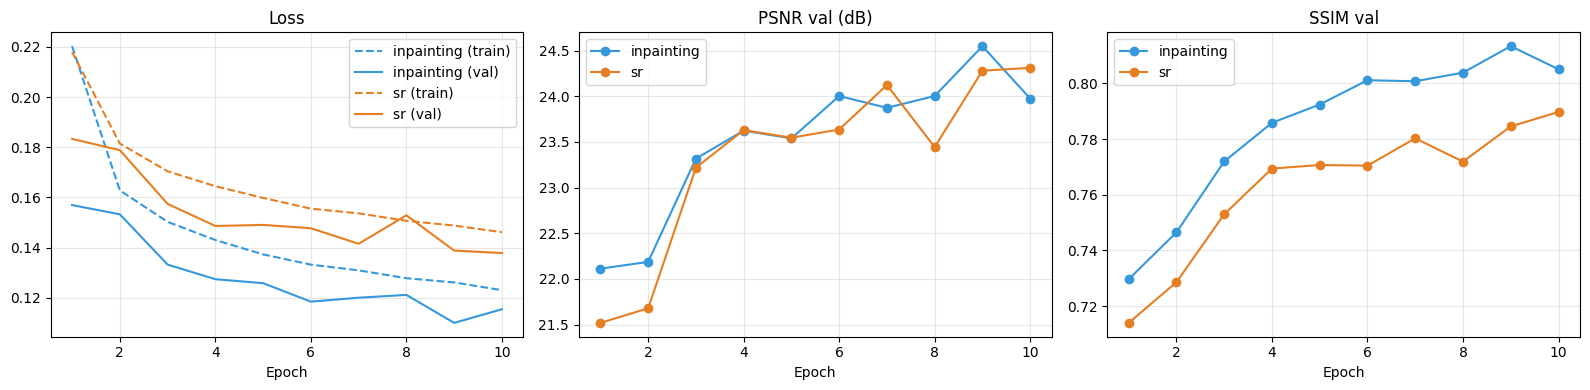

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for name, hist, color in [('inpainting', hist_inpaint, '#3498db'), ('sr', hist_sr, '#e67e22')]:
    axes[0].plot(hist['epoch'], hist['train_loss'], label=f'{name} (train)', color=color, linestyle='--')
    axes[0].plot(hist['epoch'], hist['val_loss'],   label=f'{name} (val)',   color=color)
    axes[1].plot(hist['epoch'], hist['val_psnr'], label=name, color=color, marker='o')
    axes[2].plot(hist['epoch'], hist['val_ssim'], label=name, color=color, marker='o')
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].set_title('PSNR val (dB)'); axes[1].set_xlabel('Epoch'); axes[1].legend(); axes[1].grid(alpha=0.3)
axes[2].set_title('SSIM val'); axes[2].set_xlabel('Epoch'); axes[2].legend(); axes[2].grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [13]:
# Évaluation sur le test complet
criterion = CombinedLoss(CONFIG['lambda_perc']).to(DEVICE)

test_results = {}
for task, model in [('inpainting', model_inpaint), ('sr', model_sr)]:
    loaders = build_dataloaders(index_df, task=task, cfg=CONFIG)
    loss, p, s = evaluate(model, loaders['test'], criterion)
    test_results[task] = {'loss': loss, 'psnr': p, 'ssim': s}
    print(f"  {task:10} | loss={loss:.4f}  PSNR={p:.2f}dB  SSIM={s:.4f}")

df_res = pd.DataFrame(test_results).T
df_res.columns = ['Test Loss', 'Test PSNR (dB)', 'Test SSIM']
print("\n📊 Résultats sur le test set (2 000 images) :")
print(df_res.round(4).to_string())

  ✓ VGG16 perceptual loss chargée
  inpainting | loss=0.1106  PSNR=24.35dB  SSIM=0.8144
  sr         | loss=0.1379  PSNR=24.22dB  SSIM=0.7919

📊 Résultats sur le test set (2 000 images) :
            Test Loss  Test PSNR (dB)  Test SSIM
inpainting     0.1106         24.3472     0.8144
sr             0.1379         24.2202     0.7919


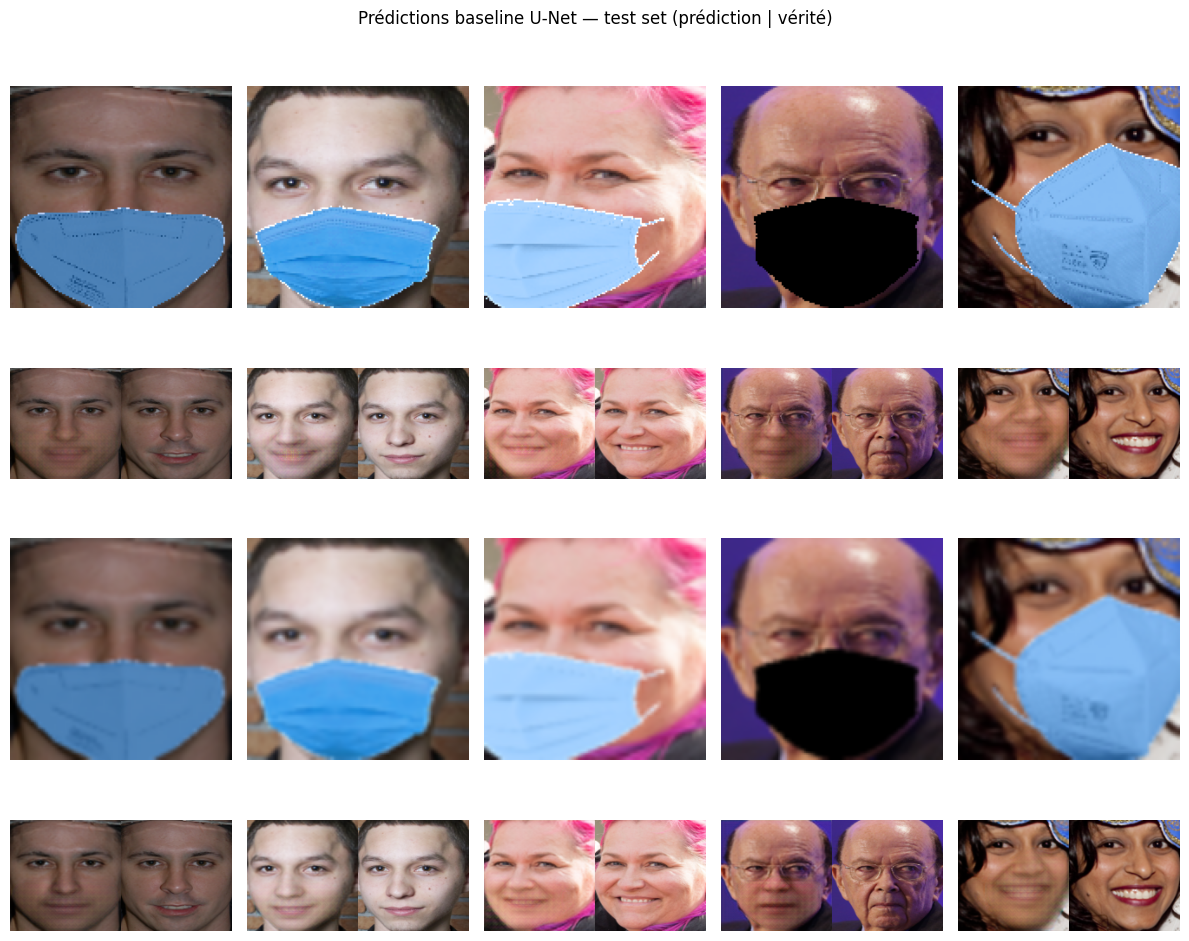

In [14]:
# Visualisation qualitative : 5 exemples du test set par tâche
def to_plot(t):
    return MaskedFaceDataset.denormalize(t).permute(1,2,0).numpy()

n_show = 5
fig, axes = plt.subplots(4, n_show, figsize=(2.4*n_show, 10))

for row_task, (task, model) in enumerate([('inpainting', model_inpaint), ('sr', model_sr)]):
    test_df = index_df[index_df['split']=='test'].sample(n_show, random_state=SEED).reset_index(drop=True)
    ds = MaskedFaceDataset(test_df, task=task, lr_size=CONFIG['lr_size'], hr_size=CONFIG['hr_size'])
    model.eval()
    with torch.no_grad():
        for i in range(n_show):
            x, y = ds[i]
            yh = model(x.unsqueeze(0).to(DEVICE)).squeeze(0).cpu()
            r_in = row_task * 2
            r_pred = row_task * 2 + 1
            # Si SR, on upsample l'input pour affichage cohérent
            x_show = TF.resize(x, [CONFIG['hr_size']]*2, antialias=True) if task=='sr' else x
            axes[r_in, i].imshow(to_plot(x_show)); axes[r_in, i].axis('off')
            axes[r_pred, i].imshow(np.concatenate([to_plot(yh), to_plot(y)], axis=1))
            axes[r_pred, i].axis('off')
            if i == 0:
                axes[r_in, i].set_ylabel(f'{task}\ninput', rotation=0, labelpad=40, fontsize=10)
                axes[r_pred, i].set_ylabel(f'{task}\npred | target', rotation=0, labelpad=40, fontsize=10)

plt.suptitle('Prédictions baseline U-Net — test set (prédiction | vérité)', y=1.01)
plt.tight_layout(); plt.show()

## 11. Sauvegarde des checkpoints

Les poids + la config + l'historique pour pouvoir reprendre ou évaluer plus tard sans ré-entraîner.

In [15]:
for task, model, hist in [('inpainting', model_inpaint, hist_inpaint),
                           ('sr',        model_sr,      hist_sr)]:
    ckpt_path = OUTPUT_DIR / f'unet_{task}_best.pt'
    torch.save({
        'task'    : task,
        'config'  : CONFIG,
        'state'   : model.state_dict(),
        'history' : hist,
        'test'    : test_results[task],
    }, ckpt_path)
    size_mb = ckpt_path.stat().st_size / 1e6
    print(f"✓ {ckpt_path.name} sauvé ({size_mb:.1f} MB)")

# Historique combiné en JSON (léger, lisible)
with open(OUTPUT_DIR / 'training_summary.json', 'w') as f:
    json.dump({
        'config'  : CONFIG,
        'inpainting': {'history': hist_inpaint, 'test': test_results['inpainting']},
        'sr'      : {'history': hist_sr,      'test': test_results['sr']},
    }, f, indent=2, default=str)
print(f"✓ training_summary.json sauvé")

✓ unet_inpainting_best.pt sauvé (31.1 MB)
✓ unet_sr_best.pt sauvé (31.1 MB)
✓ training_summary.json sauvé


## 12. Synthèse

In [16]:
print("="*65)
print("📋 BASELINE U-NET — RÉSULTATS")
print("="*65)
print(f"\n▸ Config : {CONFIG['epochs']} epochs, batch={CONFIG['batch_size']}, lr={CONFIG['lr']}")
print(f"▸ Paires train/val/test : {(index_df['split']=='train').sum():,} / {(index_df['split']=='val').sum():,} / {(index_df['split']=='test').sum():,}")
print(f"\n▸ RÉSULTATS TEST SET")
print(df_res.round(4).to_string())

# Diagnostic
inp_psnr, sr_psnr = test_results['inpainting']['psnr'], test_results['sr']['psnr']
inp_ssim, sr_ssim = test_results['inpainting']['ssim'], test_results['sr']['ssim']
print(f"\n▸ INTERPRÉTATION")
if inp_psnr > sr_psnr + 1:
    print(f"   • Inpainting > SR de {inp_psnr-sr_psnr:.2f} dB — attendu (SR a la tâche supplémentaire du 2× upscaling)")
elif sr_psnr > inp_psnr + 1:
    print(f"   • SR > inpainting de {sr_psnr-inp_psnr:.2f} dB — surprenant, à investiguer")
else:
    print(f"   • Performances comparables (écart {abs(inp_psnr-sr_psnr):.2f} dB)")

if inp_psnr < 22:
    print("   ⚠️  PSNR faible → le modèle sous-apprend. Pistes : +epochs, +capacité, loss plus agressive")
elif inp_psnr < 28:
    print("   ✓ PSNR correct pour un baseline — marge nette pour GAN/diffusion")
else:
    print("   ✓ PSNR élevé — le baseline est solide, GAN apportera surtout du réalisme perceptuel")

print(f"\n▸ PROCHAINES ÉTAPES POSSIBLES")
print("   A. GAN : ajouter un discriminateur PatchGAN → meilleur réalisme (textures peau)")
print("   B. Diffusion : DDPM conditionné sur masked → état-de-l'art mais lent")
print("   C. Améliorer le baseline : +epochs, LR scheduling, more augmentations")

📋 BASELINE U-NET — RÉSULTATS

▸ Config : 10 epochs, batch=32, lr=0.0002
▸ Paires train/val/test : 16,000 / 2,000 / 2,000

▸ RÉSULTATS TEST SET
            Test Loss  Test PSNR (dB)  Test SSIM
inpainting     0.1106         24.3472     0.8144
sr             0.1379         24.2202     0.7919

▸ INTERPRÉTATION
   • Performances comparables (écart 0.13 dB)
   ✓ PSNR correct pour un baseline — marge nette pour GAN/diffusion

▸ PROCHAINES ÉTAPES POSSIBLES
   A. GAN : ajouter un discriminateur PatchGAN → meilleur réalisme (textures peau)
   B. Diffusion : DDPM conditionné sur masked → état-de-l'art mais lent
   C. Améliorer le baseline : +epochs, LR scheduling, more augmentations
